# ResNet-1D — ECG Multi-Label Classification
## PTB-XL+ · 500 Hz · 5 classes: NORM, MI, STTC, CD, HYP

## Celda 1 · Imports y configuración

In [1]:
import sys, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score,
    recall_score, accuracy_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
    multilabel_confusion_matrix,
)
from tqdm.auto import tqdm

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAME      = "resnet1d"
SAMPLING_RATE   = 500
BATCH_SIZE      = 128
NUM_WORKERS     = 0
EPOCHS          = 150
PATIENCE        = 25
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
WARMUP_EPOCHS   = 10
MIXUP_ALPHA     = 0.4
LABEL_SMOOTHING = 0.05
GRAD_CLIP       = 1.0
CLASS_NAMES     = ["NORM", "MI", "STTC", "CD", "HYP"]

DATA_PATH       = PROJECT_ROOT / "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
RESULTS_DIR     = PROJECT_ROOT / "results"
FIGURES_DIR     = RESULTS_DIR / "figures"
METRICS_DIR     = RESULTS_DIR / "metrics"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

for d in [FIGURES_DIR, METRICS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12})
print(f"Results → {RESULTS_DIR}")


Device: cuda
Results → C:\Personal\UP\ML2\ecg-classification\results


In [2]:
import torch
print("CUDA disponible:", torch.cuda.is_available())
print("Versión PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No detectada")
print("Device:", device)

CUDA disponible: True
Versión PyTorch: 2.12.0+cu130
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
Device: cuda


## Celda 2 · Dataset, normalización y DataLoaders

Loaded pre-computed norm stats from C:\Personal\UP\ML2\ecg-classification\config\norm_stats.npy
Saved normalizer stats to C:\Personal\UP\ML2\ecg-classification\results\metrics\resnet1d_norm_stats.npy
pos_weight: tensor([1.2930, 2.9776, 3.2618, 3.4582, 7.2199])

Split sizes → train:17418, val:2183, test:2198
Batch shape → X:torch.Size([128, 12, 5000]), y:torch.Size([128, 5])


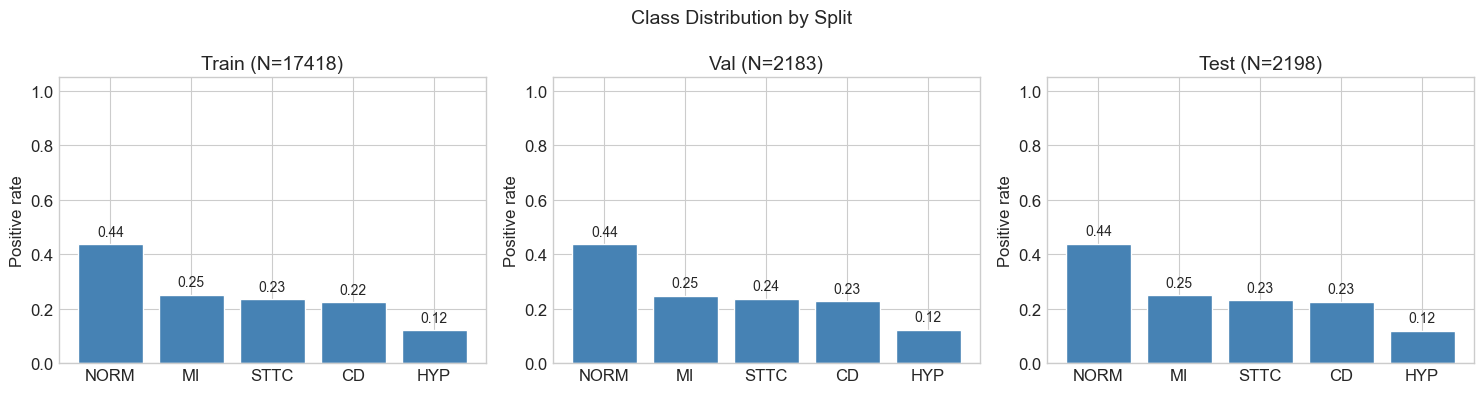

In [3]:
from data.dataset import PTBXLDataset
from data.preprocessing import (
    fit_normalizer, normalize, save_norm_stats, load_norm_stats,
    default_train_transforms,
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Download PTB-XL+ from PhysioNet and place it in the project root."
    )

# ── Normalization stats ────────────────────────────────────────────
# Uses pre-computed stats from scripts/preprocess.py by default.
# Set use_precomputed=False to recompute (requires ~4 GB RAM).
use_precomputed = True
config_stats = PROJECT_ROOT / "config" / "norm_stats.npy"

if use_precomputed and config_stats.exists():
    mean, std = load_norm_stats(config_stats)
    print(f"Loaded pre-computed norm stats from {config_stats}")
else:
    print("Computing norm stats from training set (may take a while)…")
    _tmp_ds = PTBXLDataset(DATA_PATH, split="train", sampling_rate=SAMPLING_RATE)
    _tmp_loader = DataLoader(_tmp_ds, batch_size=64, shuffle=False, num_workers=0)
    _X_list = []
    for _X, _ in tqdm(_tmp_loader, desc="Loading train signals"):
        _X_list.append(_X.numpy())
    _X_train = np.concatenate(_X_list, axis=0)   # (N, 12, L)
    mean, std = fit_normalizer(_X_train)
    del _X_train, _X_list
    print(f"Computed norm stats. mean.shape={mean.shape}")

save_norm_stats(mean, std, METRICS_DIR / f"{MODEL_NAME}_norm_stats.npy")
norm_stats = (mean, std)

# ── pos_weight ─────────────────────────────────────────────────────
pos_weight_path = PROJECT_ROOT / "data" / "processed" / "pos_weight.npy"
if not pos_weight_path.exists():
    raise FileNotFoundError(
        f"pos_weight.npy not found: {pos_weight_path}\n"
        "Run: python scripts/preprocess.py"
    )
pos_weight = torch.tensor(np.load(str(pos_weight_path)), dtype=torch.float32)
print(f"pos_weight: {pos_weight}")

# ── Datasets & DataLoaders ─────────────────────────────────────────
train_transform = default_train_transforms(signal_length=5000)

train_ds = PTBXLDataset(DATA_PATH, split="train", sampling_rate=SAMPLING_RATE,
                         transform=train_transform, norm_stats=norm_stats)
val_ds   = PTBXLDataset(DATA_PATH, split="val",   sampling_rate=SAMPLING_RATE,
                         norm_stats=norm_stats)
test_ds  = PTBXLDataset(DATA_PATH, split="test",  sampling_rate=SAMPLING_RATE,
                         norm_stats=norm_stats)

print(f"\nSplit sizes → train:{len(train_ds)}, val:{len(val_ds)}, test:{len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=0, pin_memory=False)

X_s, y_s = next(iter(train_loader))
print(f"Batch shape → X:{X_s.shape}, y:{y_s.shape}")

# ── Class distribution bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (ds, title) in zip(axes, [(train_ds,"Train"),(val_ds,"Val"),(test_ds,"Test")]):
    labels = ds.get_all_labels()
    freqs  = labels.mean(axis=0)
    bars   = ax.bar(CLASS_NAMES, freqs, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} (N={len(ds)})")
    ax.set_ylabel("Positive rate")
    ax.set_ylim(0, 1.05)
    for bar, f in zip(bars, freqs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{f:.2f}", ha="center", va="bottom", fontsize=10)
plt.suptitle("Class Distribution by Split", fontsize=14)
plt.tight_layout()
plt.show()


## Celda 3 · Modelo

In [4]:
from models.resnet1d import ResNet1D

try:
    from torchinfo import summary as tinfo_summary
    HAS_TORCHINFO = True
except ImportError:
    HAS_TORCHINFO = False
    print("torchinfo not installed. pip install torchinfo")

model = ResNet1D(n_classes=5, drop_path_rate=0.3, sampling_rate=SAMPLING_RATE).to(device)

if HAS_TORCHINFO:
    tinfo_summary(model, input_size=(BATCH_SIZE, 12, 5000),
                  col_names=["input_size","output_size","num_params","mult_adds"], depth=4)
else:
    n  = sum(p.numel() for p in model.parameters())
    nt = sum(p.numel() for p in model.parameters() if p.requires_grad)
    sz = sum(p.numel()*p.element_size() for p in model.parameters()) / 1e6
    print(f"Total params:     {n:,}")
    print(f"Trainable params: {nt:,}")
    print(f"Model size (MB):  {sz:.1f}")


## Celda 4 · Entrenamiento

In [5]:
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
warmup_sched = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=max(EPOCHS - WARMUP_EPOCHS, 1), eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS])
criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
scaler       = torch.amp.GradScaler('cuda') if device.type == "cuda" else None
_pw          = pos_weight.to(device)

def mixup_batch(x, y, alpha):
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def smooth_bce(logits, targets, smoothing):
    t = targets * (1 - smoothing) + 0.5 * smoothing
    return F.binary_cross_entropy_with_logits(logits, t, pos_weight=_pw)

history = {"train_loss":[], "val_loss":[], "val_macro_auc":[], "val_macro_f1":[], "learning_rate":[]}
best_auc, best_epoch, patience_counter = 0.0, 0, 0
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_best.pt"
t0 = time.time()

for epoch in range(EPOCHS):
    # ── train ──────────────────────────────────────────────────────
    model.train()
    train_losses = []
    for X, y in tqdm(train_loader, desc=f"Ep {epoch+1}/{EPOCHS} [train]", leave=False):
        X, y = X.to(device), y.to(device)
        X, y_a, y_b, lam = mixup_batch(X, y, MIXUP_ALPHA)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                logits = model(X)
                loss = lam * smooth_bce(logits, y_a, LABEL_SMOOTHING) + \
                       (1 - lam) * smooth_bce(logits, y_b, LABEL_SMOOTHING)
            scaler.scale(loss).backward()
            if GRAD_CLIP > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(X)
            loss = lam * smooth_bce(logits, y_a, LABEL_SMOOTHING) + \
                   (1 - lam) * smooth_bce(logits, y_b, LABEL_SMOOTHING)
            loss.backward()
            if GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        train_losses.append(loss.item())

    # ── validate ───────────────────────────────────────────────────
    model.eval()
    val_losses, vl, vt = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            val_losses.append(criterion(logits, y).item())
            vl.append(torch.sigmoid(logits).cpu())
            vt.append(y.cpu())

    vp = torch.cat(vl).numpy()
    vy = torch.cat(vt).numpy()
    val_auc = float(roc_auc_score(vy, vp, average="macro"))
    val_f1  = float(f1_score(vy, (vp >= 0.5).astype(int), average="macro", zero_division=0))
    lr_now  = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(float(np.mean(train_losses)))
    history["val_loss"].append(float(np.mean(val_losses)))
    history["val_macro_auc"].append(val_auc)
    history["val_macro_f1"].append(val_f1)
    history["learning_rate"].append(lr_now)
    scheduler.step()

    # ── checkpoint + early stopping ────────────────────────────────
    if val_auc > best_auc:
        best_auc, best_epoch, patience_counter = val_auc, epoch, 0
        torch.save({
            "epoch": epoch, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_auc": val_auc, "history": history,
        }, ckpt_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

    print(f"Ep {epoch+1:3d} | train={history['train_loss'][-1]:.4f} "
          f"| val={history['val_loss'][-1]:.4f} | auc={val_auc:.4f} | f1={val_f1:.4f} "
          f"| lr={lr_now:.2e}")

    torch.cuda.empty_cache()
    import gc; gc.collect()

training_time_minutes = (time.time() - t0) / 60
ckpt = torch.load(ckpt_path, map_location="cpu")
ckpt["training_time_minutes"] = training_time_minutes
torch.save(ckpt, ckpt_path)
print(f"\nBest val AUC={best_auc:.4f} @ epoch {best_epoch+1}")
print(f"Training time: {training_time_minutes:.1f} min | checkpoint → {ckpt_path}")


Ep 1/150 [train]:   0%|          | 0/137 [00:00<?, ?it/s]

Ep   1 | train=1.0857 | val=0.8676 | auc=0.8210 | f1=0.5476 | lr=1.00e-05


Ep 2/150 [train]:   0%|          | 0/137 [00:00<?, ?it/s]

Ep   2 | train=0.9108 | val=0.6702 | auc=0.8913 | f1=0.6494 | lr=1.09e-04


Ep 3/150 [train]:   0%|          | 0/137 [00:00<?, ?it/s]

...

Ep  44 | train=0.6490 | val=0.5539 | auc=0.9218 | f1=0.7267 | lr=8.69e-04


Ep 45/150 [train]:   0%|          | 0/137 [00:00<?, ?it/s]

Ep  45 | train=0.6532 | val=0.5913 | auc=0.9136 | f1=0.7141 | lr=8.62e-04


Ep 46/150 [train]:   0%|          | 0/137 [00:00<?, ?it/s]


Early stopping at epoch 46.

Best val AUC=0.9298 @ epoch 21
Training time: 57.6 min | checkpoint → C:\Personal\UP\ML2\ecg-classification\results\checkpoints\resnet1d_best.pt


## Celda 5 · Evaluación — métricas completas

In [6]:
# ── Load best checkpoint ───────────────────────────────────────────
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_best.pt"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
history = ckpt["history"]
best_epoch = ckpt["epoch"]
training_time_minutes = ckpt.get("training_time_minutes", 0.0)
print(f"Loaded checkpoint  epoch={best_epoch+1}  val_auc={ckpt['val_auc']:.4f}")

# ── PASO 1: Optimal threshold per class on VAL set ─────────────────
model.eval()
vl, vt = [], []
with torch.no_grad():
    for X, y in tqdm(val_loader, desc="Val inference"):
        vl.append(torch.sigmoid(model(X.to(device))).cpu())
        vt.append(y.cpu())

val_proba = torch.cat(vl).numpy()
val_true  = torch.cat(vt).numpy()

thresholds = []
for i, cls in enumerate(CLASS_NAMES):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.91, 0.01):
        pred = (val_proba[:, i] >= t).astype(int)
        f1   = f1_score(val_true[:, i], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    thresholds.append(best_t)
    print(f"  {cls}: threshold={best_t:.2f}  val_F1={best_f1:.4f}")

np.save(str(METRICS_DIR / f"{MODEL_NAME}_thresholds.npy"), np.array(thresholds))

# ── PASO 2: Test set inference ─────────────────────────────────────
tl, tt = [], []
with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Test inference"):
        tl.append(torch.sigmoid(model(X.to(device))).cpu())
        tt.append(y.cpu())

y_pred_proba  = torch.cat(tl).numpy()
y_true        = torch.cat(tt).numpy()
y_pred_binary = (y_pred_proba >= np.array(thresholds)).astype(int)

np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_true.npy"),        y_true)
np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_pred_proba.npy"),  y_pred_proba)
np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_pred_binary.npy"), y_pred_binary)

# ── PASO 3: Metrics ────────────────────────────────────────────────
macro_auc       = roc_auc_score(y_true, y_pred_proba, average="macro")
macro_f1        = f1_score(y_true, y_pred_binary, average="macro", zero_division=0)
macro_auprc     = average_precision_score(y_true, y_pred_proba, average="macro")
weighted_f1     = f1_score(y_true, y_pred_binary, average="weighted", zero_division=0)
accuracy        = accuracy_score(y_true.argmax(axis=1), y_pred_binary.argmax(axis=1))

auc_per_class       = roc_auc_score(y_true, y_pred_proba, average=None)
f1_per_class        = f1_score(y_true, y_pred_binary, average=None, zero_division=0)
precision_per_class = precision_score(y_true, y_pred_binary, average=None, zero_division=0)
recall_per_class    = recall_score(y_true, y_pred_binary, average=None, zero_division=0)
auprc_per_class     = average_precision_score(y_true, y_pred_proba, average=None)

specificity_per_class = []
for i in range(len(CLASS_NAMES)):
    tn, fp, fn, tp = confusion_matrix(
        y_true[:, i], y_pred_binary[:, i], labels=[0, 1]
    ).ravel()
    specificity_per_class.append(float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0)

n_params    = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

if device.type == "cuda":
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = []
    model.eval()
    with torch.no_grad():
        for X, _ in test_loader:
            X = X.to(device)
            starter.record(); _ = model(X); ender.record()
            torch.cuda.synchronize()
            timings.append(starter.elapsed_time(ender) / X.shape[0])
    inference_time_ms = float(np.mean(timings))
else:
    timings = []
    with torch.no_grad():
        for X, _ in test_loader:
            X = X.to(device)
            t0_inf = time.perf_counter(); _ = model(X)
            timings.append((time.perf_counter() - t0_inf) / X.shape[0] * 1000)
    inference_time_ms = float(np.mean(timings))

# ── PASO 4: Save & print ───────────────────────────────────────────
metrics = {
    "model": MODEL_NAME, "macro_auc": float(macro_auc), "macro_f1": float(macro_f1),
    "macro_auprc": float(macro_auprc), "weighted_f1": float(weighted_f1),
    "accuracy": float(accuracy), "sensitivity": float(np.mean(recall_per_class)),
    "specificity": float(np.mean(specificity_per_class)),
    "n_params": int(n_params), "n_trainable": int(n_trainable),
    "inference_time_ms": inference_time_ms,
    "training_time_minutes": training_time_minutes,
    "auc_per_class":       [float(x) for x in auc_per_class],
    "f1_per_class":        [float(x) for x in f1_per_class],
    "precision_per_class": [float(x) for x in precision_per_class],
    "recall_per_class":    [float(x) for x in recall_per_class],
    "specificity_per_class": specificity_per_class,
    "auprc_per_class":     [float(x) for x in auprc_per_class],
    "optimal_threshold_per_class": thresholds,
}
with open(METRICS_DIR / f"{MODEL_NAME}_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

per_class_df = pd.DataFrame({
    "Class": CLASS_NAMES, "AUC": auc_per_class, "F1": f1_per_class,
    "Precision": precision_per_class, "Recall": recall_per_class,
    "Specificity": specificity_per_class, "AUPRC": auprc_per_class,
    "Threshold": thresholds,
}).set_index("Class")
per_class_df.to_csv(METRICS_DIR / f"{MODEL_NAME}_metrics.csv")

print(f"\n{'='*55}")
print(f"  {MODEL_NAME.upper()} — Test Metrics")
print(f"{'='*55}")
print(f"  Macro AUC    : {macro_auc:.4f}")
print(f"  Macro F1     : {macro_f1:.4f}")
print(f"  Macro AUPRC  : {macro_auprc:.4f}")
print(f"  Weighted F1  : {weighted_f1:.4f}")
print(f"  Accuracy     : {accuracy:.4f}")
print(f"  Params       : {n_params:,}")
print(f"  Inference    : {inference_time_ms:.2f} ms/sample")
print(f"{'='*55}")
print(per_class_df.round(4).to_string())


Loaded checkpoint  epoch=21  val_auc=0.9298


Val inference:   0%|          | 0/9 [00:00<?, ?it/s]

  NORM: threshold=0.66  val_F1=0.8629
  MI: threshold=0.53  val_F1=0.7607
  STTC: threshold=0.57  val_F1=0.7486
  CD: threshold=0.64  val_F1=0.7816
  HYP: threshold=0.76  val_F1=0.5905


Test inference:   0%|          | 0/9 [00:00<?, ?it/s]


  RESNET1D — Test Metrics
  Macro AUC    : 0.9258
  Macro F1     : 0.7409
  Macro AUPRC  : 0.8141
  Weighted F1  : 0.7747
  Accuracy     : 0.7643
  Params       : 8,914,053
  Inference    : 0.21 ms/sample
          AUC      F1  Precision  Recall  Specificity   AUPRC  Threshold
Class                                                                   
NORM   0.9509  0.8621     0.8071  0.9252       0.8275  0.9296       0.66
MI     0.9297  0.7456     0.7532  0.7382       0.9193  0.8383       0.53
STTC   0.9354  0.7568     0.7160  0.8024       0.9048  0.8217       0.57
CD     0.9095  0.7563     0.7586  0.7540       0.9301  0.8248       0.64
HYP    0.9033  0.5836     0.5115  0.6794       0.9122  0.6563       0.76


## Celda 6 · Figura 1 — Curvas ROC

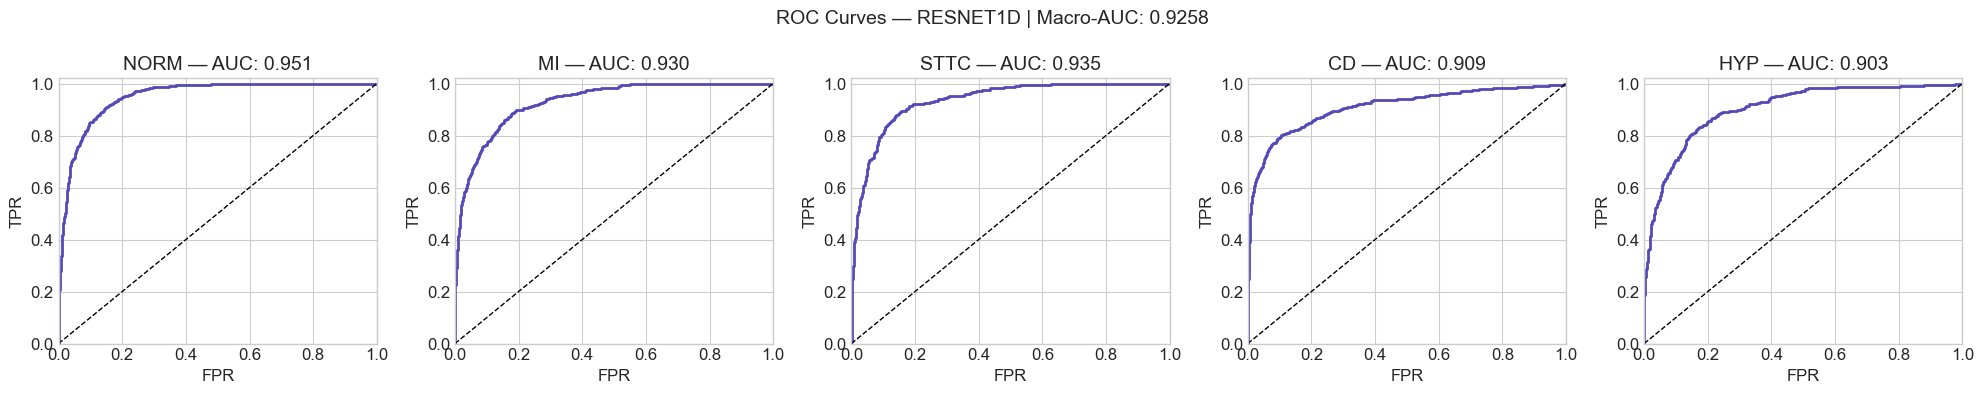

Saved ROC curves → C:\Personal\UP\ML2\ecg-classification\results\figures


In [7]:
# Figura 1 — Curvas ROC (1 fila × 5 subplots)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, lw=2, color="#534AB7")
    ax.plot([0,1], [0,1], "k--", lw=1)
    ax.set_title(f"{cls} — AUC: {auc_per_class[i]:.3f}")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle(f"ROC Curves — {MODEL_NAME.upper()} | Macro-AUC: {macro_auc:.4f}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_roc_curves{ext}", **kw)
plt.show()
print(f"Saved ROC curves → {FIGURES_DIR}")


## Celda 7 · Figura 2 — Confusion Matrix

In [ ]:
# Figura 2a — Normalized Confusion Matrix (5×5)
y_true_cls = y_true.argmax(axis=1)
y_pred_cls = y_pred_proba.argmax(axis=1)

cm = confusion_matrix(y_true_cls, y_pred_cls, labels=list(range(len(CLASS_NAMES))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, cbar=True, linewidths=0.5, vmin=0, vmax=1,
    annot_kws={"size": 12},
)
ax.set_title(
    f"Normalized Confusion Matrix — {MODEL_NAME.upper()}\n"
    f"Macro-AUC={macro_auc:.4f}  Macro-F1={macro_f1:.4f}",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_confusion_matrix{ext}", **kw)
plt.show()
print(f"Saved confusion matrix → {FIGURES_DIR}")

# ── Figura 2b — Por clase: subcondiciones SCP ──────────────────────
import ast

CLASS_CONDITIONS = {
    "NORM": ["NORM"],
    "MI":   ["IMI", "ASMI", "ILMI", "AMI", "ALMI", "LMI",
             "IPLMI", "IPMI", "PMI", "INJAS", "INJAL", "INJIN", "INJLA", "INJIL"],
    "STTC": ["NDT", "NST_", "ISC_", "ISCAL", "ISCIN", "ISCIL",
             "ISCAS", "ISCLA", "ISCAN", "ANEUR", "LNGQT", "DIG", "EL"],
    "CD":   ["CLBBB", "CRBBB", "ILBBB", "IRBBB", "LAFB", "LPFB",
             "IVCD", "1AVB", "2AVB", "3AVB", "WPW"],
    "HYP":  ["LVH", "RVH", "LAO/LAE", "RAO/RAE", "SEHYP"],
}

scp_df = pd.read_csv(DATA_PATH / "scp_statements.csv", index_col=0)
code_to_class_map = {
    code: str(row["diagnostic_class"]).strip()
    for code, row in scp_df.iterrows()
    if pd.notna(row.get("diagnostic_class", float("nan")))
}
meta_all  = pd.read_csv(DATA_PATH / "ptbxl_database.csv", index_col="ecg_id")
meta_test = meta_all[meta_all["strat_fold"] == 10].reset_index()

def parse_subconditions(scp_raw: str, target_cls: str) -> list:
    try:
        codes = ast.literal_eval(scp_raw)
    except (ValueError, SyntaxError):
        return []
    return [c for c, conf in codes.items()
            if conf > 0 and code_to_class_map.get(c) == target_cls]

CLASS_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}

for cls in CLASS_NAMES:
    conds = CLASS_CONDITIONS[cls]
    ci    = CLASS_IDX[cls]

    counts = {c: {0: 0, 1: 0} for c in conds}
    for sample_idx, (_, row_meta) in enumerate(meta_test.iterrows()):
        for sc in parse_subconditions(row_meta["scp_codes"], cls):
            if sc in counts:
                counts[sc][int(y_pred_binary[sample_idx, ci])] += 1

    df_pivot = pd.DataFrame(
        {"FN": [counts[c][0] for c in conds],
         "TP": [counts[c][1] for c in conds]},
        index=conds,
    )
    df_pivot = df_pivot[df_pivot.sum(axis=1) > 0]
    if df_pivot.empty:
        print(f"Sin datos para {cls}, saltando.")
        continue

    df_norm = df_pivot.div(df_pivot.sum(axis=1).replace(0, 1), axis=0)

    fig, ax = plt.subplots(figsize=(4.5, max(2.0, len(df_pivot) * 0.28 + 1.2)))
    sns.heatmap(df_norm, annot=True, fmt=".2f", cmap="Blues",
                ax=ax, cbar=True, linewidths=0.5, vmin=0, vmax=1,
                annot_kws={"size": 8})
    ax.set_title(
        f"{cls}  |  AUC={auc_per_class[ci]:.3f}  F1={f1_per_class[ci]:.3f}  Thr={thresholds[ci]:.2f}",
        fontsize=9, fontweight="bold",
    )
    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("SCP subcondition", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=8)
    ax.yaxis.set_tick_params(rotation=0)
    plt.tight_layout()
    for ext in (".pdf", ".png"):
        kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
        plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_confusion_{cls}{ext}", **kw)
    plt.show()
    print(f"Saved → {FIGURES_DIR / f'{MODEL_NAME}_confusion_{cls}.png'}")

## Celda 8 · Figura 3 — Curvas de entrenamiento

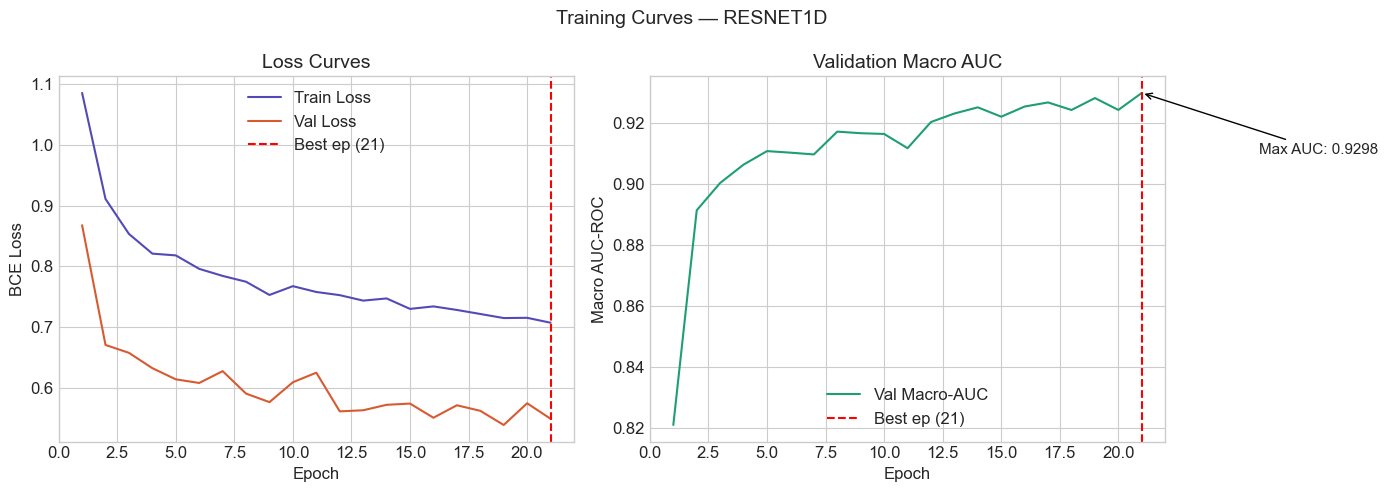

Saved training curves → C:\Personal\UP\ML2\ecg-classification\results\figures


In [9]:
# Figura 3 — Curvas de entrenamiento
epochs_r = range(1, len(history["train_loss"]) + 1)
best_ep  = ckpt["epoch"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_r, history["train_loss"], label="Train Loss", color="#534AB7")
ax.plot(epochs_r, history["val_loss"],   label="Val Loss",   color="#D85A30")
ax.axvline(best_ep+1, color="red", ls="--", lw=1.5, label=f"Best ep ({best_ep+1})")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("Loss Curves"); ax.legend()

ax = axes[1]
ax.plot(epochs_r, history["val_macro_auc"], label="Val Macro-AUC", color="#1D9E75")
ax.axvline(best_ep+1, color="red", ls="--", lw=1.5, label=f"Best ep ({best_ep+1})")
best_val = history["val_macro_auc"][best_ep]
ax.annotate(f"Max AUC: {best_val:.4f}",
            xy=(best_ep+1, best_val), xytext=(best_ep+6, best_val-0.02),
            arrowprops=dict(arrowstyle="->"), fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("Macro AUC-ROC")
ax.set_title("Validation Macro AUC"); ax.legend()

plt.suptitle(f"Training Curves — {MODEL_NAME.upper()}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_training_curves{ext}", **kw)
plt.show()
print(f"Saved training curves → {FIGURES_DIR}")


## Celda 9 · Figura 4 — Curvas Precision-Recall

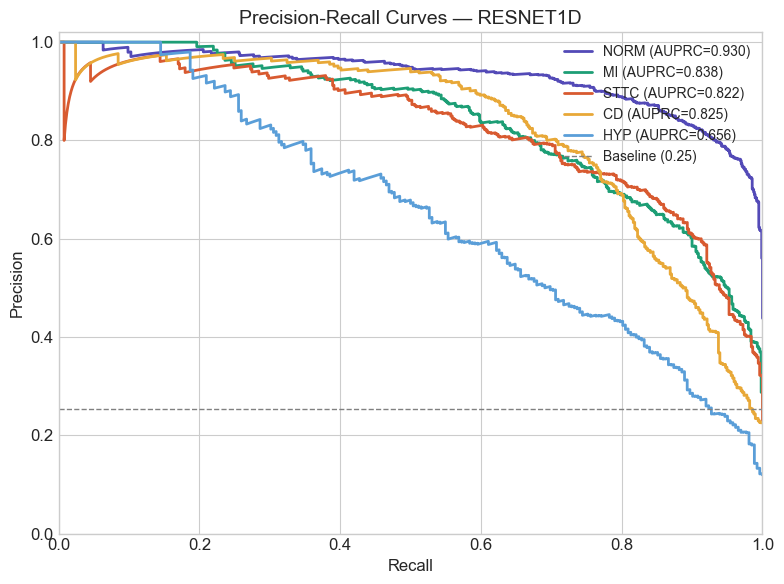

Saved PR curves → C:\Personal\UP\ML2\ecg-classification\results\figures


In [10]:
# Figura 4 — Curvas Precision-Recall
COLORS_5 = ["#534AB7", "#1D9E75", "#D85A30", "#E8A838", "#5A9ED8"]
fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, col) in enumerate(zip(CLASS_NAMES, COLORS_5)):
    prec, rec, _ = precision_recall_curve(y_true[:, i], y_pred_proba[:, i])
    ax.plot(rec, prec, lw=2, label=f"{cls} (AUPRC={auprc_per_class[i]:.3f})", color=col)
baseline = y_true.mean()
ax.axhline(baseline, ls="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curves — {MODEL_NAME.upper()}")
ax.legend(loc="upper right", fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_pr_curves{ext}", **kw)
plt.show()
print(f"Saved PR curves → {FIGURES_DIR}")


## Celda 10 · Figura 5 — F1 y AUC por clase

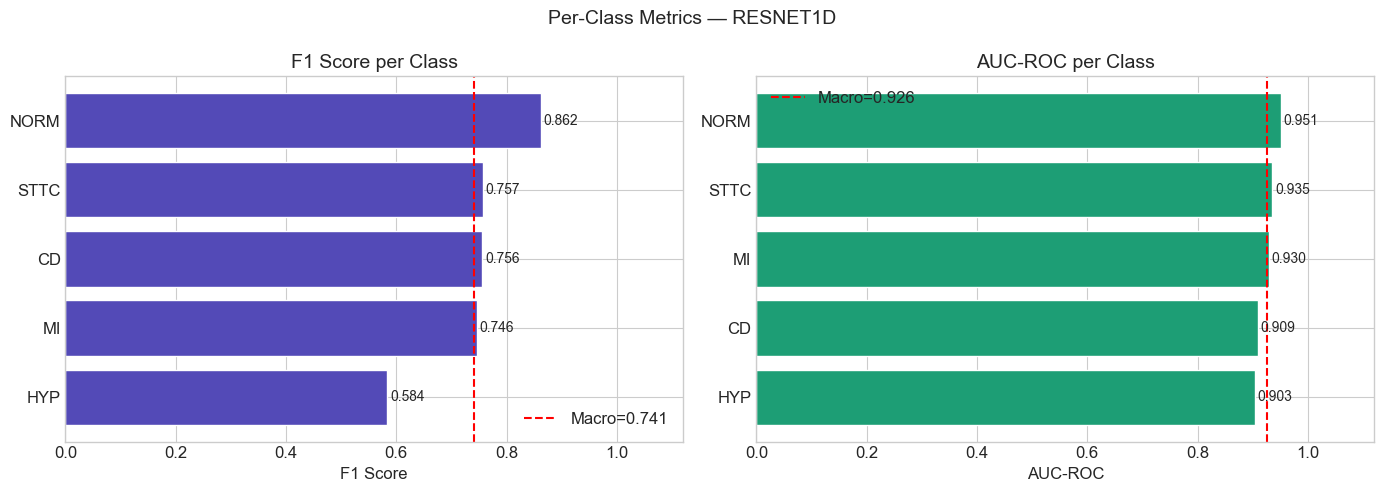

Saved per-class metrics → C:\Personal\UP\ML2\ecg-classification\results\figures


In [11]:
# Figura 5 — F1 y AUC por clase (barras horizontales)
f1_sorted  = sorted(zip(f1_per_class,  CLASS_NAMES), reverse=True)
auc_sorted = sorted(zip(auc_per_class, CLASS_NAMES), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sorted_data, macro_val, label, color in [
    (axes[0], f1_sorted,  macro_f1,  "F1 Score",  "#534AB7"),
    (axes[1], auc_sorted, macro_auc, "AUC-ROC",   "#1D9E75"),
]:
    vals, classes = zip(*sorted_data)
    bars = ax.barh(classes[::-1], vals[::-1], color=color, edgecolor="white")
    ax.axvline(macro_val, color="red", ls="--", lw=1.5, label=f"Macro={macro_val:.3f}")
    for bar, val in zip(bars, vals[::-1]):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=10)
    ax.set_xlabel(label); ax.set_title(f"{label} per Class")
    ax.set_xlim([0, 1.12]); ax.legend()

plt.suptitle(f"Per-Class Metrics — {MODEL_NAME.upper()}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_per_class_metrics{ext}", **kw)
plt.show()
print(f"Saved per-class metrics → {FIGURES_DIR}")
